In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer

In [2]:
merged_dataset = pd.read_parquet("../data/final_merged_dataset.parquet")

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
merged_dataset.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,day_windgust,day_cloudcover,day_moonphase,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,day_of_week,hour,day_datetime,day_sunrise,day_sunset,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow,region_key,region_id,alarm_active,alarm_minutes_in_hour,isw_topic_0,isw_topic_1,isw_topic_2,isw_topic_3,isw_topic_4,isw_topic_5,isw_topic_6,isw_topic_7,isw_topic_8,isw_topic_9,isw_topic_10,isw_topic_11,isw_topic_12,isw_topic_13,isw_topic_14,isw_topic_15,isw_topic_16,isw_topic_17,isw_topic_18,isw_topic_19,isw_topic_20,isw_topic_21,isw_topic_22,isw_topic_23,isw_topic_24,isw_topic_25,isw_topic_26,isw_topic_27,isw_topic_28,isw_topic_29,isw_topic_30,isw_topic_31,isw_topic_32,isw_topic_33,isw_topic_34,isw_topic_35,isw_topic_36,isw_topic_37,isw_topic_38,isw_topic_39,isw_topic_40,isw_topic_41,isw_topic_42,isw_topic_43,isw_topic_44,isw_topic_45,isw_topic_46,isw_topic_47,isw_topic_48,isw_topic_49,isw_topic_50,isw_topic_51,isw_topic_52,isw_topic_53,isw_topic_54,isw_topic_55,isw_topic_56,isw_topic_57,isw_topic_58,isw_topic_59,isw_topic_60,isw_topic_61,isw_topic_62,isw_topic_63,isw_topic_64,isw_topic_65,isw_topic_66,isw_topic_67,isw_topic_68,isw_topic_69,isw_topic_70,isw_topic_71,isw_topic_72,isw_topic_73,isw_topic_74,isw_topic_75,isw_topic_76,isw_topic_77,isw_topic_78,isw_topic_79,isw_topic_80,isw_topic_81,isw_topic_82,isw_topic_83,isw_topic_84,isw_topic_85,isw_topic_86,isw_topic_87,isw_topic_88,isw_topic_89,isw_topic_90,isw_topic_91,isw_topic_92,isw_topic_93,isw_topic_94,isw_topic_95,isw_topic_96,isw_topic_97,isw_topic_98,isw_topic_99,isw_topic_100,isw_topic_101,isw_topic_102,isw_topic_103,isw_topic_104,isw_topic_105,isw_topic_106,isw_topic_107,isw_topic_108,isw_topic_109,isw_topic_110,isw_topic_111,isw_topic_112,isw_topic_113,isw_topic_114,isw_topic_115,isw_topic_116,isw_topic_117,isw_topic_118,isw_topic_119,isw_topic_120,isw_topic_121,isw_topic_122,isw_topic_123,isw_topic_124,isw_topic_125,isw_topic_126,isw_topic_127,isw_topic_128,isw_topic_129,isw_topic_130,isw_topic_131,isw_topic_132,isw_topic_133,isw_topic_134,isw_topic_135,isw_topic_136,isw_topic_137,isw_topic_138,isw_topic_139,isw_topic_140,isw_topic_141,isw_topic_142,isw_topic_143,isw_topic_144,isw_topic_145,isw_topic_146,isw_topic_147,isw_topic_148,isw_topic_149,tg_topic_0,tg_topic_1,tg_topic_2,tg_topic_3,tg_topic_4,tg_topic_5,tg_topic_6,tg_topic_7,tg_topic_8,tg_topic_9,tg_topic_10,tg_topic_11,tg_topic_12,tg_topic_13,tg_topic_14,tg_topic_15,tg_topic_16,tg_topic_17,tg_topic_18,tg_topic_19,tg_topic_20,tg_topic_21,tg_topic_22,tg_topic_23,tg_topic_24,tg_topic_25,tg_topic_26,tg_topic_27,tg_topic_28,tg_topic_29,tg_topic_30,tg_topic_31,tg_topic_32,tg_topic_33,tg_topic_34,tg_topic_35,tg_topic_36,tg_topic_37,tg_topic_38,tg_topic_39,tg_topic_40,tg_topic_41,tg_topic_42,tg_topic_43,tg_topic_44,tg_topic_45,tg_topic_46,tg_topic_47,tg_topic_48,tg_topic_49,tg_topic_50,tg_topic_51,tg_topic_52,tg_topic_53,tg_topic_54,tg_topic_55,tg_topic_56,tg_topic_57,tg_topic_58,tg_topic_59,tg_topic_60,tg_topic_61,tg_topic_62,tg_topic_63,tg_topic_64,tg_topic_65,tg_topic_66,tg_topic_67,tg_topic_68,tg_topic_69,tg_topic_70,tg_topic_71,tg_topic_72,tg_topic_73,tg_topic_74,tg_topic_75,tg_topic_76,tg_topic_77,tg_topic_78,tg_topic_79,tg_topic_80,tg_topic_81,tg_topic_82,tg_topic_83,tg_topic_84,tg_topic_85,tg_topic_86,tg_topic_87,tg_topic_88,tg_topic_89,tg_topic_90,tg_topic_91,tg_topic_92,tg_topic_93,tg_topic_94,tg_topic_95,tg_topic_96,tg_topic_97,tg_topic_98,tg_topic_99,tg_topic_100,tg_topic_101,tg_topic_102,tg_topic_103,tg_topic_104,tg_topic_105,tg_topic_106,tg_topic_107,tg_topic_108,tg_topic_109,tg_topic_110,tg_topic_111,tg_topic_112,tg_topic_113,tg_topic_114,tg_topic_115,tg_topic_116,tg_topic_11

In [5]:
merged_dataset.tail()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,day_windgust,day_cloudcover,day_moonphase,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,day_of_week,hour,day_datetime,day_sunrise,day_sunset,hour_conditions_simple_Clear,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow,region_key,region_id,alarm_active,alarm_minutes_in_hour,isw_topic_0,isw_topic_1,isw_topic_2,isw_topic_3,isw_topic_4,isw_topic_5,isw_topic_6,isw_topic_7,isw_topic_8,isw_topic_9,isw_topic_10,isw_topic_11,isw_topic_12,isw_topic_13,isw_topic_14,isw_topic_15,isw_topic_16,isw_topic_17,isw_topic_18,isw_topic_19,isw_topic_20,isw_topic_21,isw_topic_22,isw_topic_23,isw_topic_24,isw_topic_25,isw_topic_26,isw_topic_27,isw_topic_28,isw_topic_29,isw_topic_30,isw_topic_31,isw_topic_32,isw_topic_33,isw_topic_34,isw_topic_35,isw_topic_36,isw_topic_37,isw_topic_38,isw_topic_39,isw_topic_40,isw_topic_41,isw_topic_42,isw_topic_43,isw_topic_44,isw_topic_45,isw_topic_46,isw_topic_47,isw_topic_48,isw_topic_49,isw_topic_50,isw_topic_51,isw_topic_52,isw_topic_53,isw_topic_54,isw_topic_55,isw_topic_56,isw_topic_57,isw_topic_58,isw_topic_59,isw_topic_60,isw_topic_61,isw_topic_62,isw_topic_63,isw_topic_64,isw_topic_65,isw_topic_66,isw_topic_67,isw_topic_68,isw_topic_69,isw_topic_70,isw_topic_71,isw_topic_72,isw_topic_73,isw_topic_74,isw_topic_75,isw_topic_76,isw_topic_77,isw_topic_78,isw_topic_79,isw_topic_80,isw_topic_81,isw_topic_82,isw_topic_83,isw_topic_84,isw_topic_85,isw_topic_86,isw_topic_87,isw_topic_88,isw_topic_89,isw_topic_90,isw_topic_91,isw_topic_92,isw_topic_93,isw_topic_94,isw_topic_95,isw_topic_96,isw_topic_97,isw_topic_98,isw_topic_99,isw_topic_100,isw_topic_101,isw_topic_102,isw_topic_103,isw_topic_104,isw_topic_105,isw_topic_106,isw_topic_107,isw_topic_108,isw_topic_109,isw_topic_110,isw_topic_111,isw_topic_112,isw_topic_113,isw_topic_114,isw_topic_115,isw_topic_116,isw_topic_117,isw_topic_118,isw_topic_119,isw_topic_120,isw_topic_121,isw_topic_122,isw_topic_123,isw_topic_124,isw_topic_125,isw_topic_126,isw_topic_127,isw_topic_128,isw_topic_129,isw_topic_130,isw_topic_131,isw_topic_132,isw_topic_133,isw_topic_134,isw_topic_135,isw_topic_136,isw_topic_137,isw_topic_138,isw_topic_139,isw_topic_140,isw_topic_141,isw_topic_142,isw_topic_143,isw_topic_144,isw_topic_145,isw_topic_146,isw_topic_147,isw_topic_148,isw_topic_149,tg_topic_0,tg_topic_1,tg_topic_2,tg_topic_3,tg_topic_4,tg_topic_5,tg_topic_6,tg_topic_7,tg_topic_8,tg_topic_9,tg_topic_10,tg_topic_11,tg_topic_12,tg_topic_13,tg_topic_14,tg_topic_15,tg_topic_16,tg_topic_17,tg_topic_18,tg_topic_19,tg_topic_20,tg_topic_21,tg_topic_22,tg_topic_23,tg_topic_24,tg_topic_25,tg_topic_26,tg_topic_27,tg_topic_28,tg_topic_29,tg_topic_30,tg_topic_31,tg_topic_32,tg_topic_33,tg_topic_34,tg_topic_35,tg_topic_36,tg_topic_37,tg_topic_38,tg_topic_39,tg_topic_40,tg_topic_41,tg_topic_42,tg_topic_43,tg_topic_44,tg_topic_45,tg_topic_46,tg_topic_47,tg_topic_48,tg_topic_49,tg_topic_50,tg_topic_51,tg_topic_52,tg_topic_53,tg_topic_54,tg_topic_55,tg_topic_56,tg_topic_57,tg_topic_58,tg_topic_59,tg_topic_60,tg_topic_61,tg_topic_62,tg_topic_63,tg_topic_64,tg_topic_65,tg_topic_66,tg_topic_67,tg_topic_68,tg_topic_69,tg_topic_70,tg_topic_71,tg_topic_72,tg_topic_73,tg_topic_74,tg_topic_75,tg_topic_76,tg_topic_77,tg_topic_78,tg_topic_79,tg_topic_80,tg_topic_81,tg_topic_82,tg_topic_83,tg_topic_84,tg_topic_85,tg_topic_86,tg_topic_87,tg_topic_88,tg_topic_89,tg_topic_90,tg_topic_91,tg_topic_92,tg_topic_93,tg_topic_94,tg_topic_95,tg_topic_96,tg_topic_97,tg_topic_98,tg_topic_99,tg_topic_100,tg_topic_101,tg_topic_102,tg_topic_103,tg_topic_104,tg_topic_105,tg_topic_106,tg_topic_107,tg_topic_108,tg_topic_109,tg_topic_110,tg_topic_111,tg_topic_112,tg_topic_113,tg_topic_114,tg_topic_115,tg_topic_116,tg_topic_11

In [6]:
merged_dataset.shape

(854112, 465)

In [7]:
merged_dataset.keys()

Index(['city_name', 'datetime_hour', 'day_tempmax', 'day_tempmin', 'day_temp',
       'day_dew', 'day_humidity', 'day_precip', 'day_precipcover', 'day_snow',
       ...
       'isw_topic_entropy', 'isw_velocity_24h', 'isw_intensity_ema',
       'tg_total_intensity', 'tg_topic_std', 'tg_topic_max',
       'tg_topic_entropy', 'tg_velocity_3h', 'tg_intensity_ema_6h',
       'tg_intensity_zscore'],
      dtype='object', length=465)

In [8]:
merged_dataset["target_24h"] = (
    merged_dataset
    .groupby("region_id")["alarm_active"]
    .shift(-24)
)

In [9]:
merged_dataset = merged_dataset.dropna(subset=["target_24h"])

In [10]:
y = merged_dataset["target_24h"]
X = merged_dataset.drop(columns=["alarm_active", "target_24h", "day_sunset", "day_sunrise", "day_datetime"], errors="ignore")

In [11]:
alarm_related = [col for col in X.columns if "alarm" in col.lower() or "lag" in col.lower()]
print(alarm_related)

['alarm_minutes_in_hour', 'alarm_lag_1', 'alarm_lag_3', 'alarm_lag_6', 'alarm_lag_12', 'alarms_in_last_24h', 'total_active_alarms_lag1', 'neighbour_alarms', 'hours_since_last_alarm']


In [12]:
X = X.select_dtypes(include=["number", "bool"]).copy()

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype("int8")

In [13]:
leak_cols = ["alarm_lag_1"]
X = X.drop(columns=leak_cols, errors="ignore")

In [14]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [15]:
print(X_train.isna().sum().sort_values(ascending=False).head(20))

day_tempmax        0
day_tempmin        0
day_temp           0
day_dew            0
day_humidity       0
day_precip         0
day_precipcover    0
day_snow           0
day_windgust       0
day_cloudcover     0
day_moonphase      0
hour_temp          0
hour_feelslike     0
hour_humidity      0
hour_dew           0
hour_precip        0
hour_snow          0
hour_snowdepth     0
hour_windgust      0
hour_windspeed     0
dtype: int64


In [16]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_np = X_train.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)

X_train_imp = imputer.fit_transform(X_train_np)
X_test_imp = imputer.transform(X_test_np)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

## Baseline Model

In [17]:
model = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    solver="liblinear",
    C=0.01
)
model.fit(X_train_scaled, y_train)
y_proba = model.predict_proba(X_test_scaled)[:, 1]
score = roc_auc_score(y_test, y_proba)

print(f"C={0.01}, ROC-AUC={score:.4f}")

C=0.01, ROC-AUC=0.7412


In [18]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

         0.0       0.90      0.85      0.87    144773
         1.0       0.36      0.48      0.41     25935

    accuracy                           0.79    170708
   macro avg       0.63      0.66      0.64    170708
weighted avg       0.82      0.79      0.80    170708

ROC-AUC: 0.7411835301867865
PR-AUC: 0.4192977751373553


In [19]:
threshold = 0.4
y_pred_custom = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

         0.0       0.91      0.71      0.80    144773
         1.0       0.28      0.63      0.39     25935

    accuracy                           0.70    170708
   macro avg       0.60      0.67      0.59    170708
weighted avg       0.82      0.70      0.74    170708



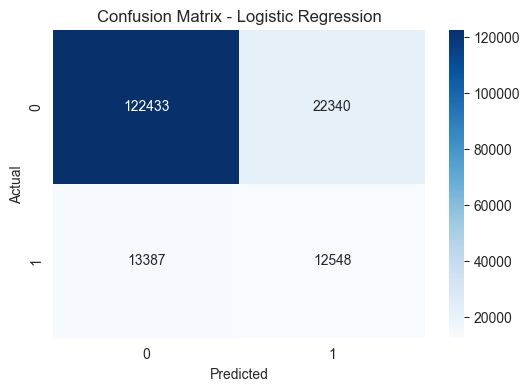

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
feature_names = X_train.columns.tolist()

coef = pd.Series(model.coef_[0], index=feature_names)
top20 = coef.abs().sort_values(ascending=False).head(20)

print(top20)

hour_solarenergy            0.984397
hour_solarradiation         0.969692
alarms_in_last_24h          0.852344
hours_since_last_alarm      0.621934
day_dew                     0.538382
hour_dew                    0.437437
day_temp                    0.417150
hour_temp                   0.346230
day_tempmin                 0.321933
neighbour_alarms            0.315695
total_active_alarms_lag1    0.297825
hour_humidity               0.275521
tg_total_intensity          0.223178
alarm_minutes_in_hour       0.191644
hour_feelslike              0.187259
day_humidity                0.179840
is_night                    0.156647
isw_topic_entropy           0.155201
tg_intensity_zscore         0.155190
tg_topic_entropy            0.149991
dtype: float64


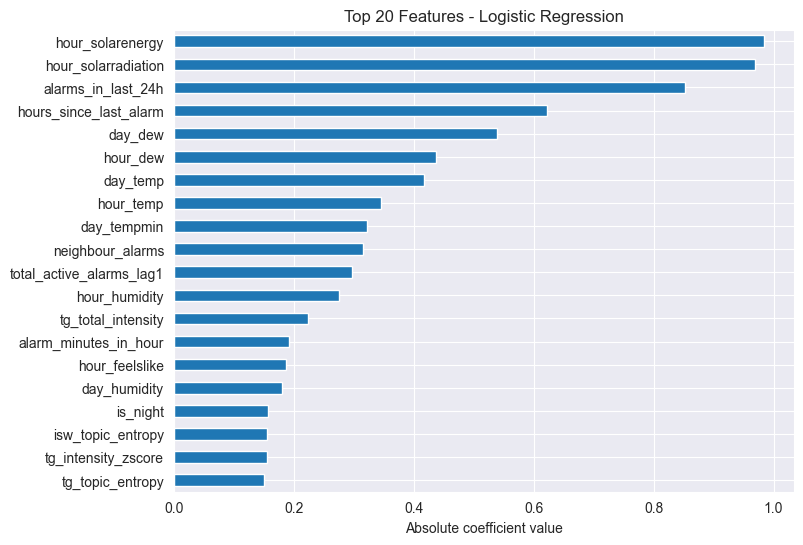

In [22]:
top20.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 20 Features - Logistic Regression")
plt.xlabel("Absolute coefficient value")
plt.show()

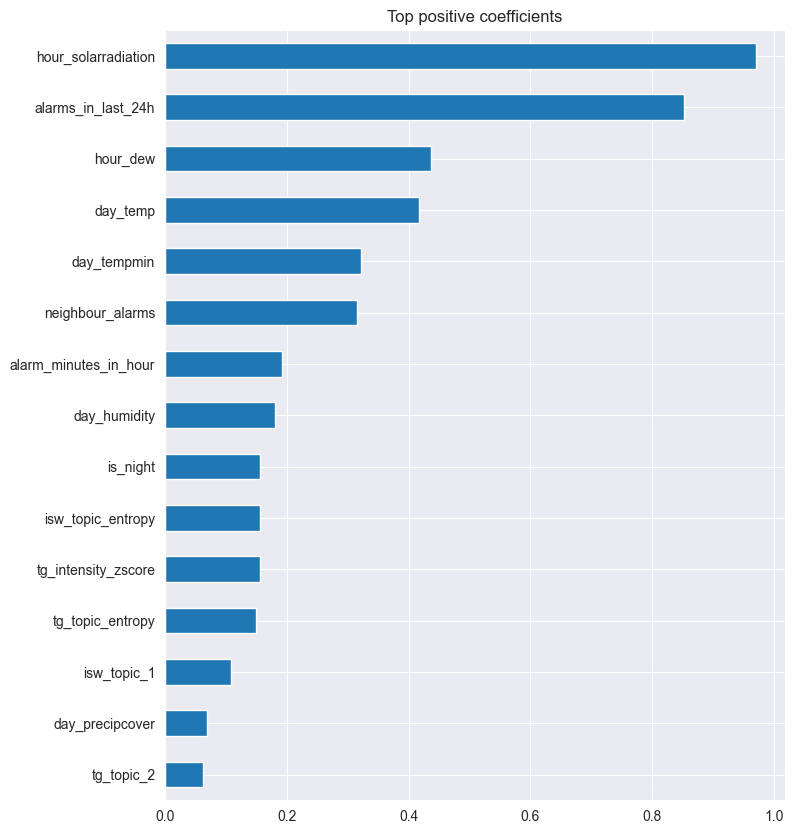

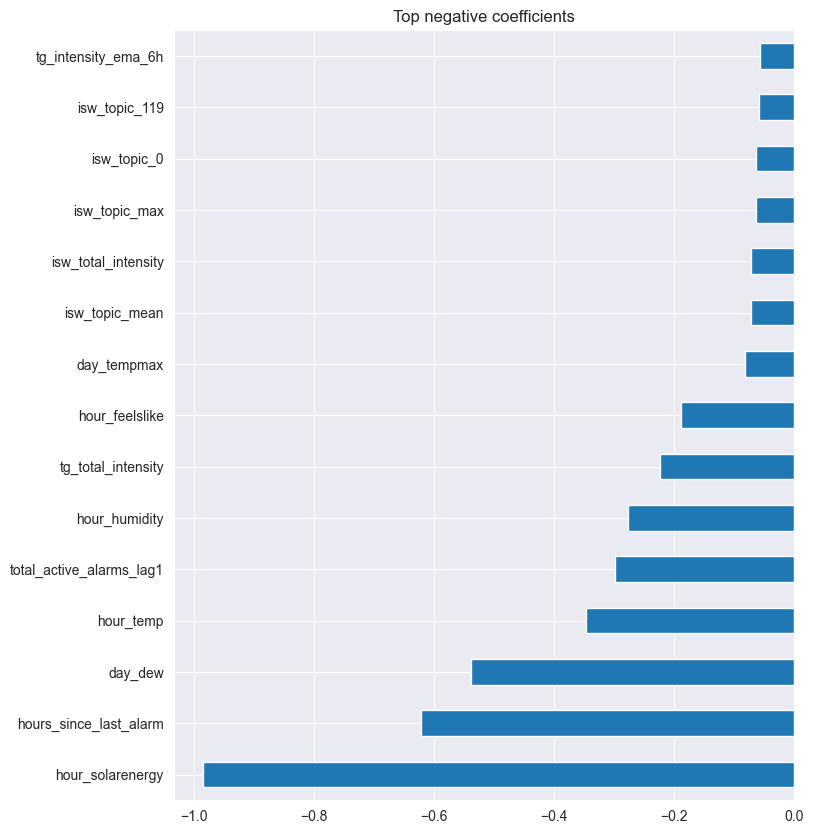

In [23]:
coef = pd.Series(model.coef_[0], index=feature_names).sort_values()

plt.figure(figsize=(8, 10))
coef.tail(15).plot(kind="barh")
plt.title("Top positive coefficients")
plt.show()

plt.figure(figsize=(8, 10))
coef.head(15).plot(kind="barh")
plt.title("Top negative coefficients")
plt.show()